<a href="https://colab.research.google.com/github/ramyanagavelli463-maker/N.Ramya/blob/main/Netflix_Data_Cleaning_Task1_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from google.colab import files

In [3]:
uploaded = files.upload()

Saving netflix_titles.csv.zip to netflix_titles.csv (1).zip


In [5]:
df = pd.read_csv("/content/netflix_titles.csv (1).zip")

print(df.head())

  show_id     type                  title         director  \
0      s1    Movie   Dick Johnson Is Dead  Kirsten Johnson   
1      s2  TV Show          Blood & Water              NaN   
2      s3  TV Show              Ganglands  Julien Leclercq   
3      s4  TV Show  Jailbirds New Orleans              NaN   
4      s5  TV Show           Kota Factory              NaN   

                                                cast        country  \
0                                                NaN  United States   
1  Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...   South Africa   
2  Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...            NaN   
3                                                NaN            NaN   
4  Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...          India   

           date_added  release_year rating   duration  \
0  September 25, 2021          2020  PG-13     90 min   
1  September 24, 2021          2021  TV-MA  2 Seasons   
2  September 24, 2021        

In [6]:
# Number of rows and columns
print(df.shape)

# Column names
print(df.columns)

# Dataset information
df.info()

# Statistical summary
print(df.describe(include="all"))

(8807, 12)
Index(['show_id', 'type', 'title', 'director', 'cast', 'country', 'date_added',
       'release_year', 'rating', 'duration', 'listed_in', 'description'],
      dtype='object')
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8807 non-null   object
 1   type          8807 non-null   object
 2   title         8807 non-null   object
 3   director      6173 non-null   object
 4   cast          7982 non-null   object
 5   country       7976 non-null   object
 6   date_added    8797 non-null   object
 7   release_year  8807 non-null   int64 
 8   rating        8803 non-null   object
 9   duration      8804 non-null   object
 10  listed_in     8807 non-null   object
 11  description   8807 non-null   object
dtypes: int64(1), object(11)
memory usage: 825.8+ KB
       show_id   type   title       director                cast 

In [7]:
# Check missing values
print(df.isnull().sum())

# Total missing values
print("Total missing values:", df.isnull().sum().sum())

show_id            0
type               0
title              0
director        2634
cast             825
country          831
date_added        10
release_year       0
rating             4
duration           3
listed_in          0
description        0
dtype: int64
Total missing values: 4307


In [9]:
# Count duplicates
print("Duplicates:", df.duplicated().sum())

# Remove duplicates
df = df.drop_duplicates()

# Check again
print("Remaining duplicates:", df.duplicated().sum())

Duplicates: 0
Remaining duplicates: 0


In [10]:
# Standardize column names
df.columns = (
    df.columns
    .str.strip()
    .str.lower()
    .str.replace(" ", "_")
)

print(df.columns)

Index(['show_id', 'type', 'title', 'director', 'cast', 'country', 'date_added',
       'release_year', 'rating', 'duration', 'listed_in', 'description'],
      dtype='object')


In [11]:
# Remove extra spaces
df["type"] = df["type"].str.strip().str.title()

df["country"] = df["country"].str.strip()

df["rating"] = df["rating"].str.strip().str.upper()

print(df["type"].unique())
print(df["rating"].unique())

['Movie' 'Tv Show']
['PG-13' 'TV-MA' 'PG' 'TV-14' 'TV-PG' 'TV-Y' 'TV-Y7' 'R' 'TV-G' 'G'
 'NC-17' '74 MIN' '84 MIN' '66 MIN' 'NR' 'UNKNOWN' 'TV-Y7-FV' 'UR']


In [12]:
# Convert date column to datetime
df["date_added"] = pd.to_datetime(
    df["date_added"],
    format="%B %d, %Y",
    errors="coerce"
)

print(df["date_added"].head())
print(df["date_added"].dtype)

0   2021-09-25
1   2021-09-24
2   2021-09-24
3   2021-09-24
4   2021-09-24
Name: date_added, dtype: datetime64[ns]
datetime64[ns]


In [13]:
print(df["date_added"].dt.strftime("%d-%m-%Y").head())

0    25-09-2021
1    24-09-2021
2    24-09-2021
3    24-09-2021
4    24-09-2021
Name: date_added, dtype: object


In [14]:
# Convert release year to integer
df["release_year"] = pd.to_numeric(
    df["release_year"], errors="coerce"
).astype("Int64")

print(df.dtypes)


show_id                 object
type                    object
title                   object
director                object
cast                    object
country                 object
date_added      datetime64[ns]
release_year             Int64
rating                  object
duration                object
listed_in               object
description             object
dtype: object


type
Movie      6131
Tv Show    2676
Name: count, dtype: int64


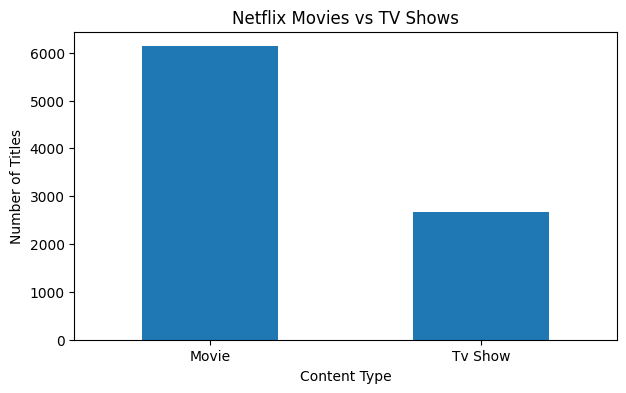

In [15]:
# Count movies and TV shows
print(df["type"].value_counts())

# Plot content types
df["type"].value_counts().plot(
    kind="bar",
    figsize=(7, 4)
)

plt.title("Netflix Movies vs TV Shows")
plt.xlabel("Content Type")
plt.ylabel("Number of Titles")
plt.xticks(rotation=0)
plt.show()

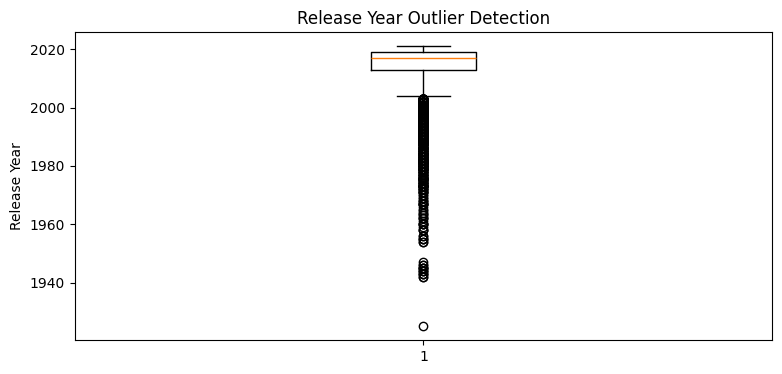

In [16]:
# Check release year distribution
plt.figure(figsize=(9, 4))

plt.boxplot(df["release_year"].dropna())

plt.title("Release Year Outlier Detection")
plt.ylabel("Release Year")
plt.show()

In [17]:
print("Final dataset shape:", df.shape)

print("\nMissing values:")
print(df.isnull().sum())

print("\nDuplicate rows:")
print(df.duplicated().sum())

print("\nData types:")
print(df.dtypes)

print("\nFirst five cleaned rows:")
print(df.head())

Final dataset shape: (8807, 12)

Missing values:
show_id          0
type             0
title            0
director         0
cast             0
country          0
date_added      98
release_year     0
rating           0
duration         0
listed_in        0
description      0
dtype: int64

Duplicate rows:
0

Data types:
show_id                 object
type                    object
title                   object
director                object
cast                    object
country                 object
date_added      datetime64[ns]
release_year             Int64
rating                  object
duration                object
listed_in               object
description             object
dtype: object

First five cleaned rows:
  show_id     type                  title         director  \
0      s1    Movie   Dick Johnson Is Dead  Kirsten Johnson   
1      s2  Tv Show          Blood & Water          Unknown   
2      s3  Tv Show              Ganglands  Julien Leclercq   
3      s4  Tv Show

In [18]:
df.to_csv("cleaned_netflix_titles.csv", index=False)

print("Cleaned dataset saved successfully!")

Cleaned dataset saved successfully!


In [19]:
files.download("cleaned_netflix_titles.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Netflix Data Cleaning Summary

Project: Netflix Movies and TV Shows Data Cleaning

Objective: To clean and preprocess Netflix data for further analysis.

Tools: Python, Pandas, NumPy, Matplotlib and Google Colab.

Tasks performed:
1. Imported and explored the Netflix dataset.
2. Identified and handled missing values.
3. Removed duplicate records.
4. Standardized column names and text values.
5. Converted date formats into datetime.
6. Corrected data types.
7. Analyzed content types using a bar chart.
8. Checked potential outliers.
9. Exported the cleaned dataset to CSV.

Conclusion: The Netflix dataset was inspected and preprocessed to make it more consistent and suitable for further analysis.